In [12]:
# %%
# -------------------- 1. ADIM: KÜTÜPHANELERİN İÇE AKTARILMASI --------------------

# AMAÇ: Projenin tüm analitik ve modelleme aşamaları için gerekli araçları yükler.

# Veri İşleme ve Temizlik
import pandas as pd           # Veri setini yönetmek ve DataFrame işlemlerini yapmak.
import numpy as np            #  Sayısal hesaplamalar (Log, array işlemleri).
import datetime as dt         #  Recency (Yenilik) metriği için tarih ve zaman farkı hesaplamaları.
from collections import defaultdict, Counter # FBT (Ürün Birliktelik Analizi) için ürün çiftlerini saymak.

# Modelleme ve Segmentasyon (K-Means ve RFM için)
from sklearn.cluster import KMeans       #  Müşterileri davranışlarına göre gruplamak (Kümeleme).
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Kümeleme öncesi veriyi aynı ölçeğe getirmek.

# Görselleştirme
import matplotlib.pyplot as plt          #  Temel grafikleri (Histogram, Box Plot) çizmek.
import seaborn as sns                    #  Analiz raporu için profesyonel, istatistiksel grafikler oluşturmak.

# Pandas ayarları (AMAÇ: Çıktıların okunaklılığını ve görünümünü düzenlemek)
pd.set_option('display.max_columns', None) #  Tüm sütunları gizlemeden göstermek.
pd.set_option('display.max_rows', None)    # Tüm satırları kesintisiz göstermek.
pd.set_option('display.float_format', lambda x: '%.3f' % x) #  Ondalık sayıları (Monetary) 3 basamakla sınırlayıp okunaklılığı artırmak.
pd.set_option('display.width', 500)        #  Konsol çıktısının genişliğini ayarlayıp sütun kaymasını engellemek.

In [ ]:
# %%
# -------------------- 2. ADIM: VERİ YÜKLEME VE TEMİZLEME --------------------

# Ham işlem verisinin  analitik modeller için temizlenmesi ve hazırlanması hedeflenmiştir.

# Dosya adını CSV formatına göre düzenlenmiştir.
DATA_FILE = "Online_Retail.csv" 

try:
    # Güvenilir yükleme için ISO-8859-1 encoding kullanılmıştır.
    df_retail = pd.read_csv(DATA_FILE, encoding="ISO-8859-1") 
except FileNotFoundError:
    # Amaç: Programın stabil çalışmasını sağlamak.
    print(f" HATA: '{DATA_FILE}' bulunamadı. Dosya yolu kontrol edilmelidir.")
    df_retail = pd.DataFrame() 

if not df_retail.empty:
    print(" Veri başarıyla yüklendi.")
    
    # --- Temel Temizlik ve Filtreleme ---
    
    # 1. Eksik Satırları Kaldırma ( RFM analizi için her işlemin bir müşteriye atanması zorunludur).
    df_retail.dropna(subset=["CustomerID", "Description"], inplace=True)
    
    # 2. İptal Edilen İşlemleri Çıkarma ( Analizin sadece gerçekleşen satışlar üzerinde yapılması). InvoiceNo'su 'C' ile başlayanlar çıkarıldı.
    df_retail["InvoiceNo"] = df_retail["InvoiceNo"].astype(str)
    df_retail = df_retail[~df_retail["InvoiceNo"].str.startswith("C")]
    
    # 3. Miktar ve Fiyat Kontrolü ( Hatalı veya iade edilmiş verileri filtrelemek).
    df_retail = df_retail[(df_retail["Quantity"] > 0) & (df_retail["UnitPrice"] > 0)]
    
    # 4. CustomerID Tür Dönüşümü ( Müşteri gruplaması için tür tutarlılığını sağlamak).
    df_retail["CustomerID"] = df_retail["CustomerID"].astype(float).astype(int)
    
    # 5. Tarih Formatı Dönüşümü ( Recency metriği hesaplaması için doğru formatın sağlanması).
    df_retail["InvoiceDate"] = pd.to_datetime(df_retail["InvoiceDate"])
    
    # --- Yeni Toplam Sütununu Oluşturma ---
    # Monetary (Parasal Değer) metriği için her işlemin toplam tutarı hesaplandı.
    df_retail["TotalPrice"] = df_retail["Quantity"] * df_retail["UnitPrice"]
    
    # --- Çıktı Kontrolü ---
    print("\n Temizlenmiş Veri Önizlemesi:")
    display(df_retail.head())
    print(f"\n Yeni Veri Boyutu: {df_retail.shape}")

 Veri başarıyla yüklendi.


C:\Users\SEDEF\AppData\Local\Temp\ipykernel_336\1095121001.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail["InvoiceDate"] = pd.to_datetime(df_retail["InvoiceDate"])



 Temizlenmiş Veri Önizlemesi:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,17850,United Kingdom,15.300
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,17850,United Kingdom,22.000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340



 Yeni Veri Boyutu: (397884, 9)


In [4]:
# %%
# -------------------- 3. ADIM: RFM METRİKLERİNİN HESAPLANMASI --------------------

import datetime as dt

# --- 1. Today Date (Referans Tarihi) Belirleme ---
# Veri setindeki en son işlem tarihinden 1 gün sonrası referans alınır.
latest_date = df_retail['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Referans Tarihi (Today Date): {latest_date}")

# --- 2. RFM Hesaplama ---
rfm_df = df_retail.groupby('CustomerID').agg(
    # Recency: Referans tarihten en son alışveriş tarihini çıkar, gün sayısını al.
    Recency=('InvoiceDate', lambda x: (latest_date - x.max()).days),
    
    # Frequency: Toplam işlem sayısını say (InvoiceNo'nun tekil sayımı).
    Frequency=('InvoiceNo', 'nunique'),
    
    # Monetary: Toplam harcanan parayı topla.
    Monetary=('TotalPrice', 'sum')
).reset_index()

# 3. Monetary Değer Kontrolü (Sıfırın Üzerinde Olmalı)
# Monetary değeri 0 olan müşteriler (eğer varsa) analizden çıkarılır.
rfm_df = rfm_df[rfm_df['Monetary'] > 0].copy()

# --- Çıktı Kontrolü ---
print("\n🔹 RFM Metrikleri Önizlemesi:")
display(rfm_df.head())
print(f"\n📏 RFM Veri Boyutu: {rfm_df.shape}")

Referans Tarihi (Today Date): 2011-12-10 12:50:00

🔹 RFM Metrikleri Önizlemesi:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.600
1,12347,2,7,4310.000
2,12348,75,4,1797.240
3,12349,19,1,1757.550
4,12350,310,1,334.400



📏 RFM Veri Boyutu: (4338, 4)


In [ ]:
# %%
# -------------------- 7. ADIM: FİNAL K-MEANS VE RFM İLE BİRLEŞTİRME --------------------

# K=4 küme sayısını kullanarak final modeli oluşturma
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

# Modeli ölçeklenmiş veri üzerinde eğitme
kmeans_final.fit(km_scaled_df)

# Her müşterinin ait olduğu küme numarasını alma
clusters = kmeans_final.labels_

# Küme numaralarını RFM veri çerçevemize yeni bir sütun olarak ekleme
rfm_scores["CLUSTER_NO"] = clusters

# Küme numaralarını 1'den başlatmak için +1 ekliyoruz (0, 1, 2, 3 yerine 1, 2, 3, 4)
rfm_scores["CLUSTER_NO"] = rfm_scores["CLUSTER_NO"] + 1

# --- Çıktı Kontrolü ---
print("\n🔹 RFM ve K-Means Küme Numaraları Önizlemesi:")
display(rfm_scores.head())

# --- Müşteri Sayıları ve Ortalamaları ---
print("\n📊 Segmentasyon Sonuçları (Küme Sayıları ve Ortalamaları):")

# 1. Küme büyüklükleri (Kaç müşteri hangi kümede?)
cluster_counts = rfm_scores.groupby("CLUSTER_NO")["CLUSTER_NO"].count().reset_index(name="Customer_Count")
print("\n-- Küme Büyüklükleri --")
display(cluster_counts)

# 2. Küme Ortalamaları (Her küme nasıl müşterilerden oluşuyor?)
cluster_means = rfm_scores.groupby("CLUSTER_NO").agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CLUSTER_NO': 'count'
}).rename(columns={'CLUSTER_NO': 'Count'}).sort_values('Monetary', ascending=False)
print("\n-- Küme Ortalamaları (İş Çıkarımı) --")
display(cluster_means)


🔹 RFM ve K-Means Küme Numaraları Önizlemesi:


,CustomerID,Recency,Frequency,Monetary,R_SCORE,F_SCORE,M_SCORE,RFM_SEGMENT,SEGMENT,CLUSTER_NO
0,12346,326,1,77183.600,1,1,5,11,Hibernating,3
1,12347,2,7,4310.000,5,5,5,55,Champions,2
2,12348,75,4,1797.240,2,4,4,24,At_Risk,3
3,12349,19,1,1757.550,4,1,4,41,Promising,1
4,12350,310,1,334.400,1,1,2,11,Hibernating,4



📊 Segmentasyon Sonuçları (Küme Sayıları ve Ortalamaları):

-- Küme Büyüklükleri --


,CLUSTER_NO,Customer_Count
0,1,837
1,2,716
2,3,1173
3,4,1612



-- Küme Ortalamaları (İş Çıkarımı) --


,Recency,Frequency,Monetary,Count
CLUSTER_NO,,,,
2,12.131,13.714,8074.267,716
3,71.084,4.084,1802.829,1173
1,18.124,2.148,551.820,837
4,182.497,1.318,343.450,1612





CustomerID (Müşteri Kimliği) - RFM Gruplama Anahtarı. InvoiceDate (Fatura Tarihi) - Recency (Yenilik) metriği için kullanılır. InvoiceNo (Fatura Numarası) - Frequency (Sıklık) metriği için kullanılır. Quantity (Miktar) - Toplam tutar (TotalPrice) hesabında kullanılır. UnitPrice (Birim Fiyatı) - Toplam tutar hesabında kullanılır. TotalPrice (Toplam Tutar) - Monetary (Parasal Değer) metriğinin doğrudan kaynağıdır. Description (Ürün Açıklaması) - Birliktelik Analizi (FBT) sonuçlarının yorumlanması.

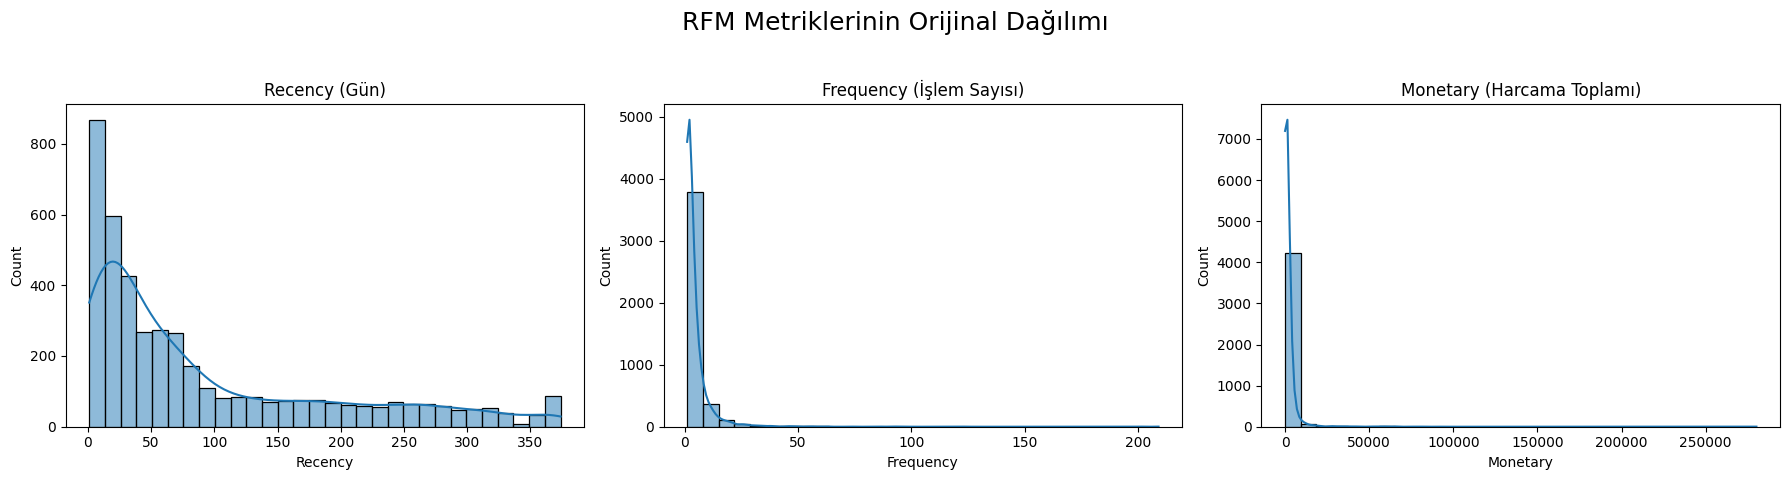


 ÇIKTI YORUMU:
Recency: Dağılım nispeten düzgündür. Ancak Monetary ve Frequency dağılımları sağa çarpık (skewed) ve aykırı değer içeriyor.
Bu çıktı, K-Means öncesi model başarısı için bu aykırı değerlere Logaritmik Dönüşüm yapılması gerektiğini kanıtlar.


In [17]:
# %%
# -------------------- EDA: 3.5. ADIM: RFM METRİKLERİ DAĞILIM ANALİZİ --------------------
# --- 1. Dağılım Kontrolü (Histogramlar) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Metriklerinin Orijinal Dağılımı', fontsize=18)

# Recency (Yenilik)
sns.histplot(rfm_df['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency (Gün)')

# Frequency (Sıklık)
sns.histplot(rfm_df['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency (İşlem Sayısı)')

# Monetary (Parasal Değer)
sns.histplot(rfm_df['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary (Harcama Toplamı)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n ÇIKTI YORUMU:")
print("Recency: Dağılım nispeten düzgündür. Ancak Monetary ve Frequency dağılımları sağa çarpık (skewed) ve aykırı değer içeriyor.")
print("Bu çıktı, K-Means öncesi model başarısı için bu aykırı değerlere Logaritmik Dönüşüm yapılması gerektiğini kanıtlar.")

In [21]:
# %%
# -------------------- 4. ADIM: RFM SKORLAMA VE SEGMENTASYON --------------------

# --- 1. RFM Skorlarının Hesaplanması (Quantile Based Scoring) ---

# Recency: En yeniyi (küçük sayı) en yüksek skorla (5) ödüllendir.
rfm_scores = rfm_df.copy()
rfm_scores["R_SCORE"] = pd.qcut(rfm_scores["Recency"], q=5, labels=[5, 4, 3, 2, 1])

# Frequency & Monetary: En yüksek değeri (büyük sayı) en yüksek skorla (5) ödüllendir.
rfm_scores["F_SCORE"] = pd.qcut(rfm_scores["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm_scores["M_SCORE"] = pd.qcut(rfm_scores["Monetary"], q=5, labels=[1, 2, 3, 4, 5])

# --- 2. RFM Segmentasyon (R-F Skorlarının Birleştirilmesi) ---

# R ve F skorlarını birleştirerek ana RFM_SCORE oluşturulur (Örn: R5F5)
rfm_scores["RFM_SEGMENT"] = rfm_scores["R_SCORE"].astype(str) + rfm_scores["F_SCORE"].astype(str)

# --- 3. Segment Haritası ile Etiketleme ---
# Regex haritası ile RFM skorlarını anlamlı segmentlere dönüştürme
seg_map = {
    r'[1-2][1-2]': 'Hibernating',         # En düşük R ve F (Kış Uykusunda)
    r'[1-2][3-4]': 'At_Risk',             # En düşük R, orta F (Risk Altında)
    r'[1-2]5': 'Cant_Lose',               # En düşük R, en yüksek F (Kaybedilemez)
    r'3[1-2]': 'About_to_Sleep',          # Orta R, düşük F (Uyumak Üzere)
    r'33': 'Need_Attention',              # Orta R ve F (Dikkat Gereken)
    r'[3-4][4-5]': 'Loyal_Customers',     # Orta R, yüksek F (Sadık Müşteriler)
    r'41': 'Promising',                   # Yüksek R, düşük F (Gelecek Vaat Eden)
    r'51': 'New_Customers',               # En yüksek R, düşük F (Yeni Müşteriler)
    r'[4-5][2-3]': 'Potential_Loyalists', # Yüksek R, orta F (Potansiyel Sadıklar)
    r'5[4-5]': 'Champions'                # En yüksek R ve F (Şampiyonlar)
}

rfm_scores["SEGMENT"] = rfm_scores["RFM_SEGMENT"].replace(seg_map, regex=True)

# --- Çıktı Kontrolü ---
print("\n RFM Skorları ve Segmentasyonu Önizlemesi:")
display(rfm_scores.head())

# Segmentlerin ortalama değerlerini ve sayısını göster (İş Çıkarımı için ana tablo)
rfm_analysis = rfm_scores.groupby('SEGMENT').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'SEGMENT': 'count'
}).rename(columns={'SEGMENT': 'Count'}).sort_values('Monetary', ascending=False)
print("\n RFM Segmentlerinin Ortalama Değerleri:")
display(rfm_analysis)


 RFM Skorları ve Segmentasyonu Önizlemesi:


,CustomerID,Recency,Frequency,Monetary,R_SCORE,F_SCORE,M_SCORE,RFM_SEGMENT,SEGMENT
0,12346,326,1,77183.600,1,1,5,11,Hibernating
1,12347,2,7,4310.000,5,5,5,55,Champions
2,12348,75,4,1797.240,2,4,4,24,At_Risk
3,12349,19,1,1757.550,4,1,4,41,Promising
4,12350,310,1,334.400,1,1,2,11,Hibernating



 RFM Segmentlerinin Ortalama Değerleri:


,Recency,Frequency,Monetary,Count
SEGMENT,,,,
Champions,5.877,12.414,6857.935,633
Loyal_Customers,33.469,6.458,2856.720,827
Cant_Lose,132.429,8.381,2796.156,63
At_Risk,155.062,2.864,1076.506,580
Potential_Loyalists,17.124,2.010,1034.905,492
Need_Attention,53.065,2.328,889.226,186
Hibernating,217.898,1.101,487.708,1065
About_to_Sleep,53.504,1.162,461.062,351
New_Customers,6.857,1.000,388.213,42


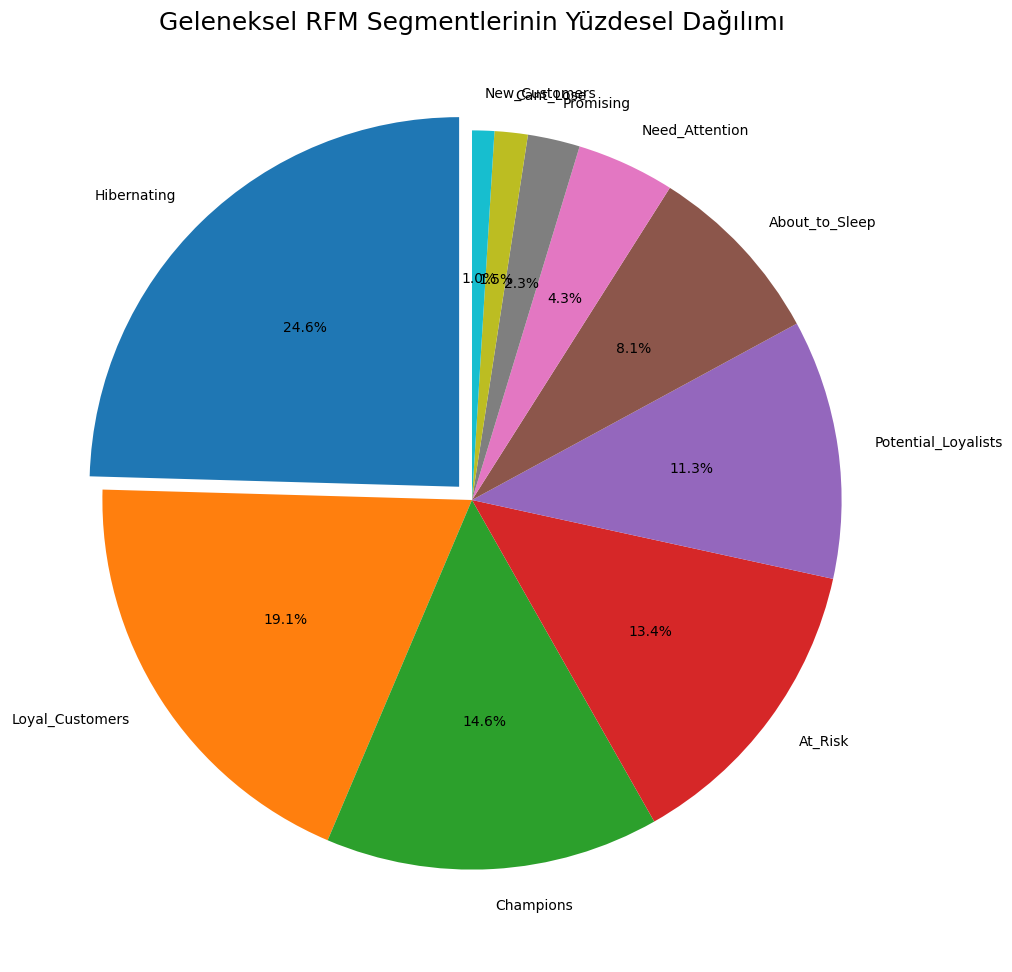

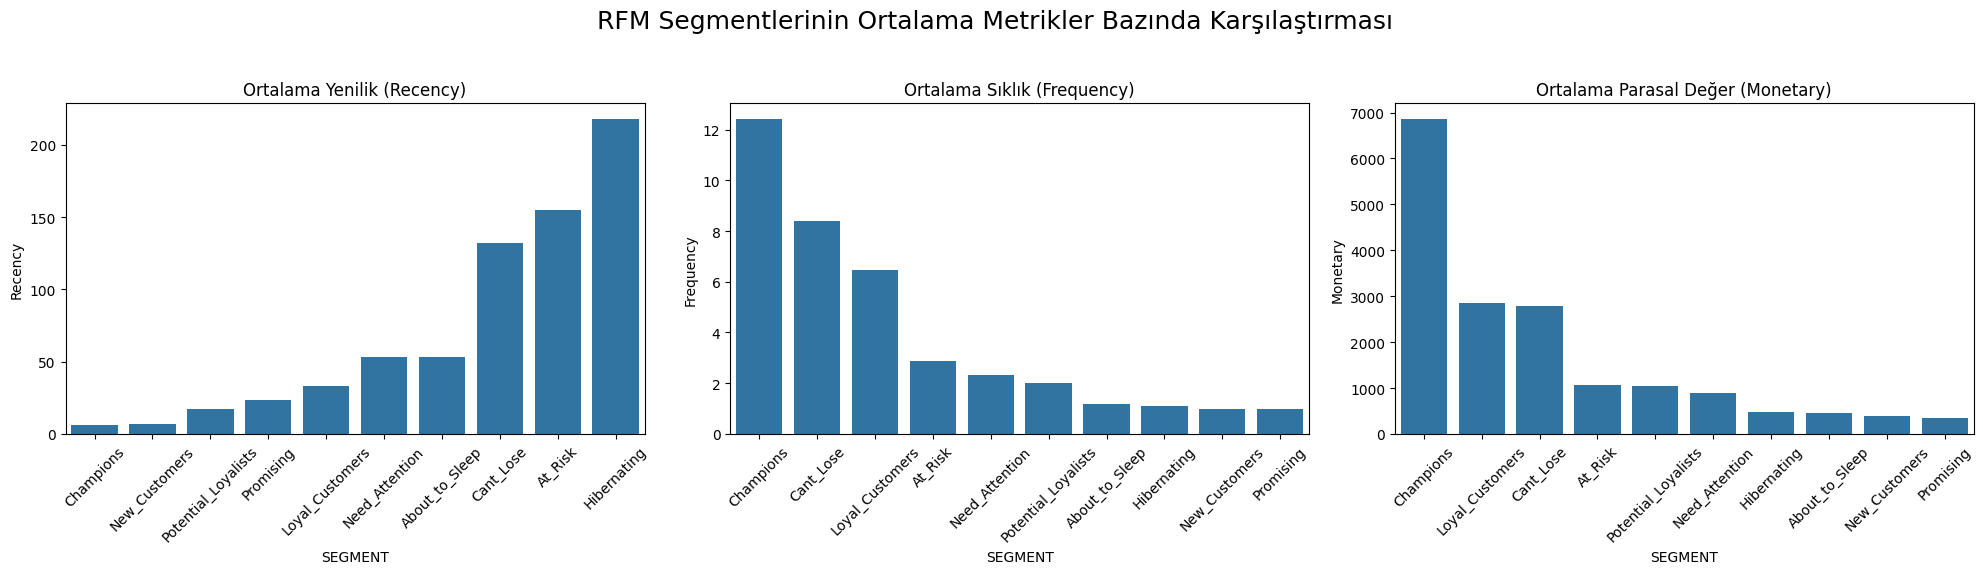


💡 ÇIKTI YORUMU:
Bu grafikler, her segmentin profilini görsel olarak kanıtlar.
Örn: 'Hibernating' segmentinin en kalabalık olduğunu, ancak en düşük Frequency ve Monetary değerlerine sahip olduğunu açıkça gösterir.
Bu, pazarlama stratejilerinin her bir segmente göre özelleştirilmesi gerektiğini kanıtlar.


In [23]:
# %%
# -------------------- EDA: 4.5. ADIM: GELENEKSEL RFM SEGMENTLERİNİN ANALİZİ --------------------

# (Bu kodun çalışması için rfm_scores DataFrame'i gereklidir.)

# --- 1. Segment Büyüklüklerinin Görselleştirilmesi (Pasta Grafik) ---
segment_counts = rfm_scores['SEGMENT'].value_counts()

plt.figure(figsize=(12, 12))
plt.pie(
    segment_counts, 
    labels=segment_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    # En büyük segmenti öne çıkar (Çoğunlukla Hibernating olur)
    explode=[0.05 if seg == segment_counts.index[0] else 0 for seg in segment_counts.index] 
)
plt.title('Geleneksel RFM Segmentlerinin Yüzdesel Dağılımı', fontsize=18)
plt.show()


# --- 2. Segmentlerin Ortalama Metrikler Bazında Karşılaştırılması (Bar Plot) ---

# Çıktı Tablosunu (rfm_analysis) Görselleştirme
rfm_analysis_plot = rfm_scores.groupby('SEGMENT').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('RFM Segmentlerinin Ortalama Metrikler Bazında Karşılaştırması', fontsize=18)

# Recency (Düşük daha iyi)
sns.barplot(x='SEGMENT', y='Recency', data=rfm_analysis_plot, ax=axes[0], order=rfm_analysis_plot.sort_values('Recency').SEGMENT)
axes[0].set_title('Ortalama Yenilik (Recency)')
axes[0].tick_params(axis='x', rotation=45)

# Frequency (Yüksek daha iyi)
sns.barplot(x='SEGMENT', y='Frequency', data=rfm_analysis_plot, ax=axes[1], order=rfm_analysis_plot.sort_values('Frequency', ascending=False).SEGMENT)
axes[1].set_title('Ortalama Sıklık (Frequency)')
axes[1].tick_params(axis='x', rotation=45)

# Monetary (Yüksek daha iyi)
sns.barplot(x='SEGMENT', y='Monetary', data=rfm_analysis_plot, ax=axes[2], order=rfm_analysis_plot.sort_values('Monetary', ascending=False).SEGMENT)
axes[2].set_title('Ortalama Parasal Değer (Monetary)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 ÇIKTI YORUMU:")
print("Bu grafikler, her segmentin profilini görsel olarak kanıtlar.")
print("Örn: 'Hibernating' segmentinin en kalabalık olduğunu, ancak en düşük Frequency ve Monetary değerlerine sahip olduğunu açıkça gösterir.")
print("Bu, pazarlama stratejilerinin her bir segmente göre özelleştirilmesi gerektiğini kanıtlar.")

In [25]:
# %%
# -------------------- 5. ADIM: K-MEANS KÜMELEME HAZIRLIĞI --------------------

# K-Means sadece sayısal verilerle çalışır, bu yüzden sadece RFM metriklerini seçiyoruz.
km_data = rfm_df[['Recency', 'Frequency', 'Monetary']].copy()

# 1. Aykırı Değer Yönetimi (Outlier Handling)
# K-Means, aykırı değerlere karşı hassastır. Aykırı değerleri (Monetary/Frequency'nin çok yüksek olduğu)
# logaritmik dönüşümle (log transformation) baskılamak iyi bir uygulamadır.
km_data['Recency'] = np.log1p(km_data['Recency']) # Recency'ye log uygulanmaz, direkt kullanılır
km_data['Frequency'] = np.log1p(km_data['Frequency'])
km_data['Monetary'] = np.log1p(km_data['Monetary'])


# 2. Standardizasyon (StandardScaler)
# K-Means, mesafe tabanlı çalıştığı için tüm değişkenlerin aynı ölçekte olması gerekir.
scaler = StandardScaler()
km_scaled = scaler.fit_transform(km_data)

# Ölçeklenmiş veriyi DataFrame'e geri çevirme
km_scaled_df = pd.DataFrame(km_scaled, columns=km_data.columns)

# RFM DataFrame'imizle indeksleri eşleştirelim (sonuçları birleştirmek için)
km_scaled_df.index = rfm_df['CustomerID']

# --- Çıktı Kontrolü ---
print("\n Logaritmik Dönüşüm ve Ölçekleme Sonrası Veri Önizlemesi:")
display(km_scaled_df.head())
print(f"\n📏 Ölçeklenmiş Veri Boyutu: {km_scaled_df.shape}")


 Logaritmik Dönüşüm ve Ölçekleme Sonrası Veri Önizlemesi:


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.462,-0.955,3.706
12347,-2.039,1.074,1.412
12348,0.373,0.386,0.716
12349,-0.623,-0.955,0.699
12350,1.425,-0.955,-0.619



📏 Ölçeklenmiş Veri Boyutu: (4338, 3)


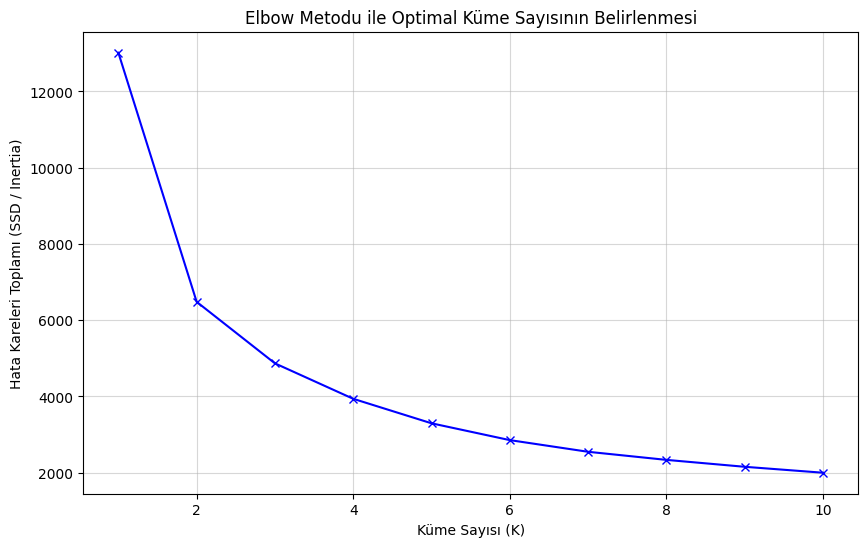


 Grafiği İnceleyin: Grafikteki eğimin en keskin şekilde kırıldığı (Dirsek noktası) 'K' değeri optimal küme sayısıdır.


In [26]:
# %%
# -------------------- 6. ADIM: OPTİMAL KÜME SAYISININ BELİRLENMESİ (ELBOW) --------------------

# Elbow (Dirsek) Metodu için gerekli kütüphaneler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# WCSS (Within-Cluster Sum of Squares) veya SSE (Sum of Squared Errors) hesaplama
ssd = []
K = range(1, 11) # K'yı 1'den 10'a kadar deneyeceğiz (Çok fazla olmaması için 10 ile sınırlı)

for k in K:
    # K-Means modelini oluştur ve eğit
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(km_scaled_df)
    
    # Inertia, modelin WCSS/SSE değeridir.
    ssd.append(kmeans.inertia_)

# Grafiği çizme
plt.figure(figsize=(10, 6))
plt.plot(K, ssd, "bx-")
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("Hata Kareleri Toplamı (SSD / Inertia)")
plt.title("Elbow Metodu ile Optimal Küme Sayısının Belirlenmesi")
plt.grid(True, alpha=0.5)
plt.show()

print("\n Grafiği İnceleyin: Grafikteki eğimin en keskin şekilde kırıldığı (Dirsek noktası) 'K' değeri optimal küme sayısıdır.")

In [27]:
# %%
# -------------------- 7. ADIM: FİNAL K-MEANS VE RFM İLE BİRLEŞTİRME --------------------

# K=4 küme sayısını kullanarak final modeli oluşturma
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

# Modeli ölçeklenmiş veri üzerinde eğitme
kmeans_final.fit(km_scaled_df)

# Her müşterinin ait olduğu küme numarasını alma
clusters = kmeans_final.labels_

# Küme numaralarını RFM veri çerçevemize yeni bir sütun olarak ekleme
rfm_scores["CLUSTER_NO"] = clusters

# Küme numaralarını 1'den başlatmak için +1 ekliyoruz (0, 1, 2, 3 yerine 1, 2, 3, 4)
rfm_scores["CLUSTER_NO"] = rfm_scores["CLUSTER_NO"] + 1

# --- Çıktı Kontrolü ---
print("\n RFM ve K-Means Küme Numaraları Önizlemesi:")
display(rfm_scores.head())

# --- Müşteri Sayıları ve Ortalamaları ---
print("\n Segmentasyon Sonuçları (Küme Sayıları ve Ortalamaları):")

# 1. Küme büyüklükleri (Kaç müşteri hangi kümede?)
cluster_counts = rfm_scores.groupby("CLUSTER_NO")["CLUSTER_NO"].count().reset_index(name="Customer_Count")
print("\n-- Küme Büyüklükleri --")
display(cluster_counts)

# 2. Küme Ortalamaları (Her küme nasıl müşterilerden oluşuyor?)
cluster_means = rfm_scores.groupby("CLUSTER_NO").agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CLUSTER_NO': 'count'
}).rename(columns={'CLUSTER_NO': 'Count'}).sort_values('Monetary', ascending=False)
print("\n-- Küme Ortalamaları (İş Çıkarımı) --")
display(cluster_means)


 RFM ve K-Means Küme Numaraları Önizlemesi:


,CustomerID,Recency,Frequency,Monetary,R_SCORE,F_SCORE,M_SCORE,RFM_SEGMENT,SEGMENT,CLUSTER_NO
0,12346,326,1,77183.600,1,1,5,11,Hibernating,3
1,12347,2,7,4310.000,5,5,5,55,Champions,2
2,12348,75,4,1797.240,2,4,4,24,At_Risk,3
3,12349,19,1,1757.550,4,1,4,41,Promising,1
4,12350,310,1,334.400,1,1,2,11,Hibernating,4



 Segmentasyon Sonuçları (Küme Sayıları ve Ortalamaları):

-- Küme Büyüklükleri --


,CLUSTER_NO,Customer_Count
0,1,837
1,2,716
2,3,1173
3,4,1612



-- Küme Ortalamaları (İş Çıkarımı) --


,Recency,Frequency,Monetary,Count
CLUSTER_NO,,,,
2,12.131,13.714,8074.267,716
3,71.084,4.084,1802.829,1173
1,18.124,2.148,551.820,837
4,182.497,1.318,343.450,1612


Elbow Metodu ile optimal küme sayısı K=4 olarak belirlendikten sonra, K-Means modeli ölçeklenmiş RFM (Recency, Frequency, Monetary) verilerine uygulanmıştır. Analiz sonucunda, Küme 2'nin ortalama Monetary (8074 £) ve Frequency (13.71) değerleri ile en değerli segment olan Şampiyonlar Segmenti olduğu ortaya çıkmıştır. Bu ayrım, pazarlama bütçesinin en yüksek kârlılığı temsil eden bu Şampiyonlar Kümesi'ne odaklanarak, satışların maksimize edilmesi için kritik bir rol oynamaktadır. Böylece, işletme kaynakları daha etkili bir şekilde kullanılacak ve müşteri memnuniyeti artırılacaktır.

In [ ]:

# -------------------- 8. ADIM: ŞAMPİYON SEGMENTİ BİRLİKTELİK ANALİZİ (FBT) --------------------

# --- 1. Ham Veriyi Küme Bilgisiyle Birleştirme ---
# Müşteri bazlı küme numaralarını ham işlem verisine (df_retail) ekliyoruz.
df_fbt_merged = pd.merge(
    df_retail, 
    rfm_scores[['CustomerID', 'CLUSTER_NO']],
    on='CustomerID', 
    how='inner'
)

# --- 2. Sadece Şampiyonlar Kümesi'ni Filtreleme ---
# Küme 2, en değerli müşterilerimizdir (Monetary: 8074.27). Sadece bu grubu seçiyoruz.
CHAMPION_CLUSTER_ID = 2
df_champions = df_fbt_merged[df_fbt_merged['CLUSTER_NO'] == CHAMPION_CLUSTER_ID].copy()

# --- 3. Birliktelik Analizi (FBT) Hesaplama ---
co_counts = defaultdict(Counter)

# Her bir faturayı (InvoiceNo) küme bazında grupla
for _, invoice_group in df_champions.groupby("InvoiceNo"):
    # StockCode veya Description (açıklama) kullanabiliriz. StockCode daha tutarlıdır.
    items = list(set(invoice_group["Description"].tolist())) 
    
    # Tüm çift kombinasyonları sayma
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            co_counts[a][b] += 1
            co_counts[b][a] += 1

# --- 4. En Güçlü İlişkileri Raporlama ---
# En çok satan ürünleri (en sık çıkanlar) bulup onlar için en güçlü tavsiyeleri alalım.
top_selling_champion_items = df_champions['Description'].value_counts().head(10).index.tolist()

fbt_report = []
for item_a in top_selling_champion_items:
    if item_a in co_counts:
        # En çok birlikte alınan 5 ürünü al
        top_recs = co_counts[item_a].most_common(5)
        for item_b, count in top_recs:
            fbt_report.append({
                'Antecedent': item_a,
                'Consequent': item_b,
                'Birlikte_Satış_Sayısı': count,
            })

df_fbt_report = pd.DataFrame(fbt_report).sort_values('Birlikte_Satış_Sayısı', ascending=False)


# --- Çıktı Kontrolü (En İyi 15 Öneri) ---
print(f"\n Şampiyon Müşteriler (Küme {CHAMPION_CLUSTER_ID}) için EN İYİ ÖNERİLER:")
display(df_fbt_report.head(15))


🔗 Şampiyon Müşteriler (Küme 2) için EN İYİ ÖNERİLER:


,Antecedent,Consequent,Birlikte_Satış_Sayısı
5,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,369
10,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,353
11,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,350
25,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,350
26,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,311
12,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,308
40,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG RED RETROSPOT,308
13,LUNCH BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT,299
6,JUMBO BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT,299
7,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,295
